# Keras-Functional-Model
[machinelearningmastery.com](https://machinelearningmastery.com/keras-functional-api-deep-learning/)

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Dense, Input, Dropout, BatchNormalization, Flatten

from keras.losses import mean_squared_error, binary_crossentropy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from keras.applications.vgg16 import VGG16
from keras.utils import plot_model
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os
import kagglehub
import random

# Load Data

In [ ]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [ ]:
image_size = (224, 224)
batch_size = 32

image_dir = os.path.join(path, 'UTKFace')

# List all image files and store their paths
image_files = []
for root, _, files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} image files in {image_dir}")

# Example of parsing filenames to extract labels
import re

def parse_filename(filepath):
    filename = os.path.basename(filepath)
    # Example filename: 1_0_0_20161219140621430.jpg.chip.jpg
    match = re.match(r'(\d+)_(\d+)_(\d+)_.*', filename)
    if match:
        age, gender, ethnicity = int(match.group(1)), int(match.group(2)), int(match.group(3))
        return age, gender, ethnicity
    return None, None, None

# Print details for a few sample images
print("\nSample image details:")
for i in range(min(5, len(image_files))):
    filepath = image_files[i]
    age, gender, ethnicity = parse_filename(filepath)
    print(f"File: {os.path.basename(filepath)} -> Age: {age}, Gender: {gender}, Ethnicity: {ethnicity}")

Found 23708 image files in /kaggle/input/utkface-new/UTKFace

Sample image details:
File: 26_0_2_20170104023102422.jpg.chip.jpg -> Age: 26, Gender: 0, Ethnicity: 2
File: 22_1_1_20170112233644761.jpg.chip.jpg -> Age: 22, Gender: 1, Ethnicity: 1
File: 21_1_3_20170105003215901.jpg.chip.jpg -> Age: 21, Gender: 1, Ethnicity: 3
File: 28_0_0_20170117180555824.jpg.chip.jpg -> Age: 28, Gender: 0, Ethnicity: 0
File: 17_1_4_20170103222931966.jpg.chip.jpg -> Age: 17, Gender: 1, Ethnicity: 4


In [ ]:
# Create a DataFrame with image paths and labels
image_data = []
for filepath in image_files:
    age, gender, ethnicity = parse_filename(filepath)
    if age is not None and gender is not None and ethnicity is not None:
        image_data.append({'path': filepath, 'age': age, 'gender': gender, 'ethnicity': ethnicity})

df = pd.DataFrame(image_data)

print(f"DataFrame created with {len(df)} entries.")
df.head()

DataFrame created with 23705 entries.


,path,age,gender,ethnicity
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0,2
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1,3
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1,4


# Train Test Split

In [ ]:
train_df = df.sample(frac=1,random_state=0).iloc[:5000]
test_df = df.sample(frac=1,random_state=0).iloc[22000:]
train_df.shape, test_df.shape

((5000, 4), (1705, 4))

# Data Augmentation

In [ ]:
def multi_output_generator(df, image_size, batch_size):
    while True:
        df = df.sample(frac=1)  # shuffle each epoch
        for start in range(0, len(df), batch_size):
            end = min(start + batch_size, len(df))
            batch_df = df.iloc[start:end]

            images = []
            age = []
            gender = []
            ethnicity = []

            for _, row in batch_df.iterrows():
                img = tf.keras.utils.load_img(row['path'], target_size=image_size)
                img = tf.keras.utils.img_to_array(img) / 255.0
                images.append(img)
                age.append(row['age'])
                gender.append(row['gender'])
                ethnicity.append(row['ethnicity'])

            X = tf.convert_to_tensor(images, dtype=tf.float32)
            y = {
                'age': tf.convert_to_tensor(age, dtype=tf.float32),
                'gender': tf.convert_to_tensor(gender, dtype=tf.float32),
                'ethnicity': tf.convert_to_tensor(ethnicity, dtype=tf.int32)
            }
            yield X, y

In [ ]:
batch_size = 64

train_generator = multi_output_generator(train_df, image_size, batch_size)
val_generator = multi_output_generator(test_df, image_size, batch_size)

# Model Load

In [ ]:
conv_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
conv_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Freez Trainable

In [ ]:
conv_model.trainable = False

## Extract Last Layer Output

In [ ]:
conv_output = conv_model.layers[-1].output

## Layers Build

In [ ]:
# Flatten Layer
flatten_layer = Flatten()(conv_output)

# Dense Layer 0
dense_layer0 = Dense(64, activation='relu')(flatten_layer)
dense_layer0 = Dropout(0.5)(dense_layer0)
dense_layer0 = BatchNormalization()(dense_layer0)

# Dense Layer 1
dense_layer1 = Dense(16, activation='relu')(dense_layer0)
dense_layer1 = Dropout(0.5)(dense_layer0)
dense_layer1 = BatchNormalization()(dense_layer0)

# Dense Layer 2
dense_layer2 = Dense(8, activation='relu')(dense_layer0)
dense_layer2 = Dropout(0.5)(dense_layer0)
dense_layer2 = BatchNormalization()(dense_layer0)

# Dense Layer 3
dense_layer3 = Dense(32, activation='relu')(dense_layer0)
dense_layer3 = Dropout(0.5)(dense_layer0)
dense_layer3 = BatchNormalization()(dense_layer0)

# Age Output
age_output = Dense(1, activation='linear', name='age')(dense_layer1)

# Gender Output
gender_output = Dense(1, activation='sigmoid', name='gender')(dense_layer2)

# Ethnicity Output
ethnicity_output = Dense(7, activation='softmax', name='ethnicity')(dense_layer3)

## Functional Model Build

In [ ]:
model = Model(inputs=conv_model.input, outputs=[age_output, gender_output, ethnicity_output])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 16,321,993 (62.26 MB)

 Trainable params: 1,606,793 (6.13 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

## Plot Model

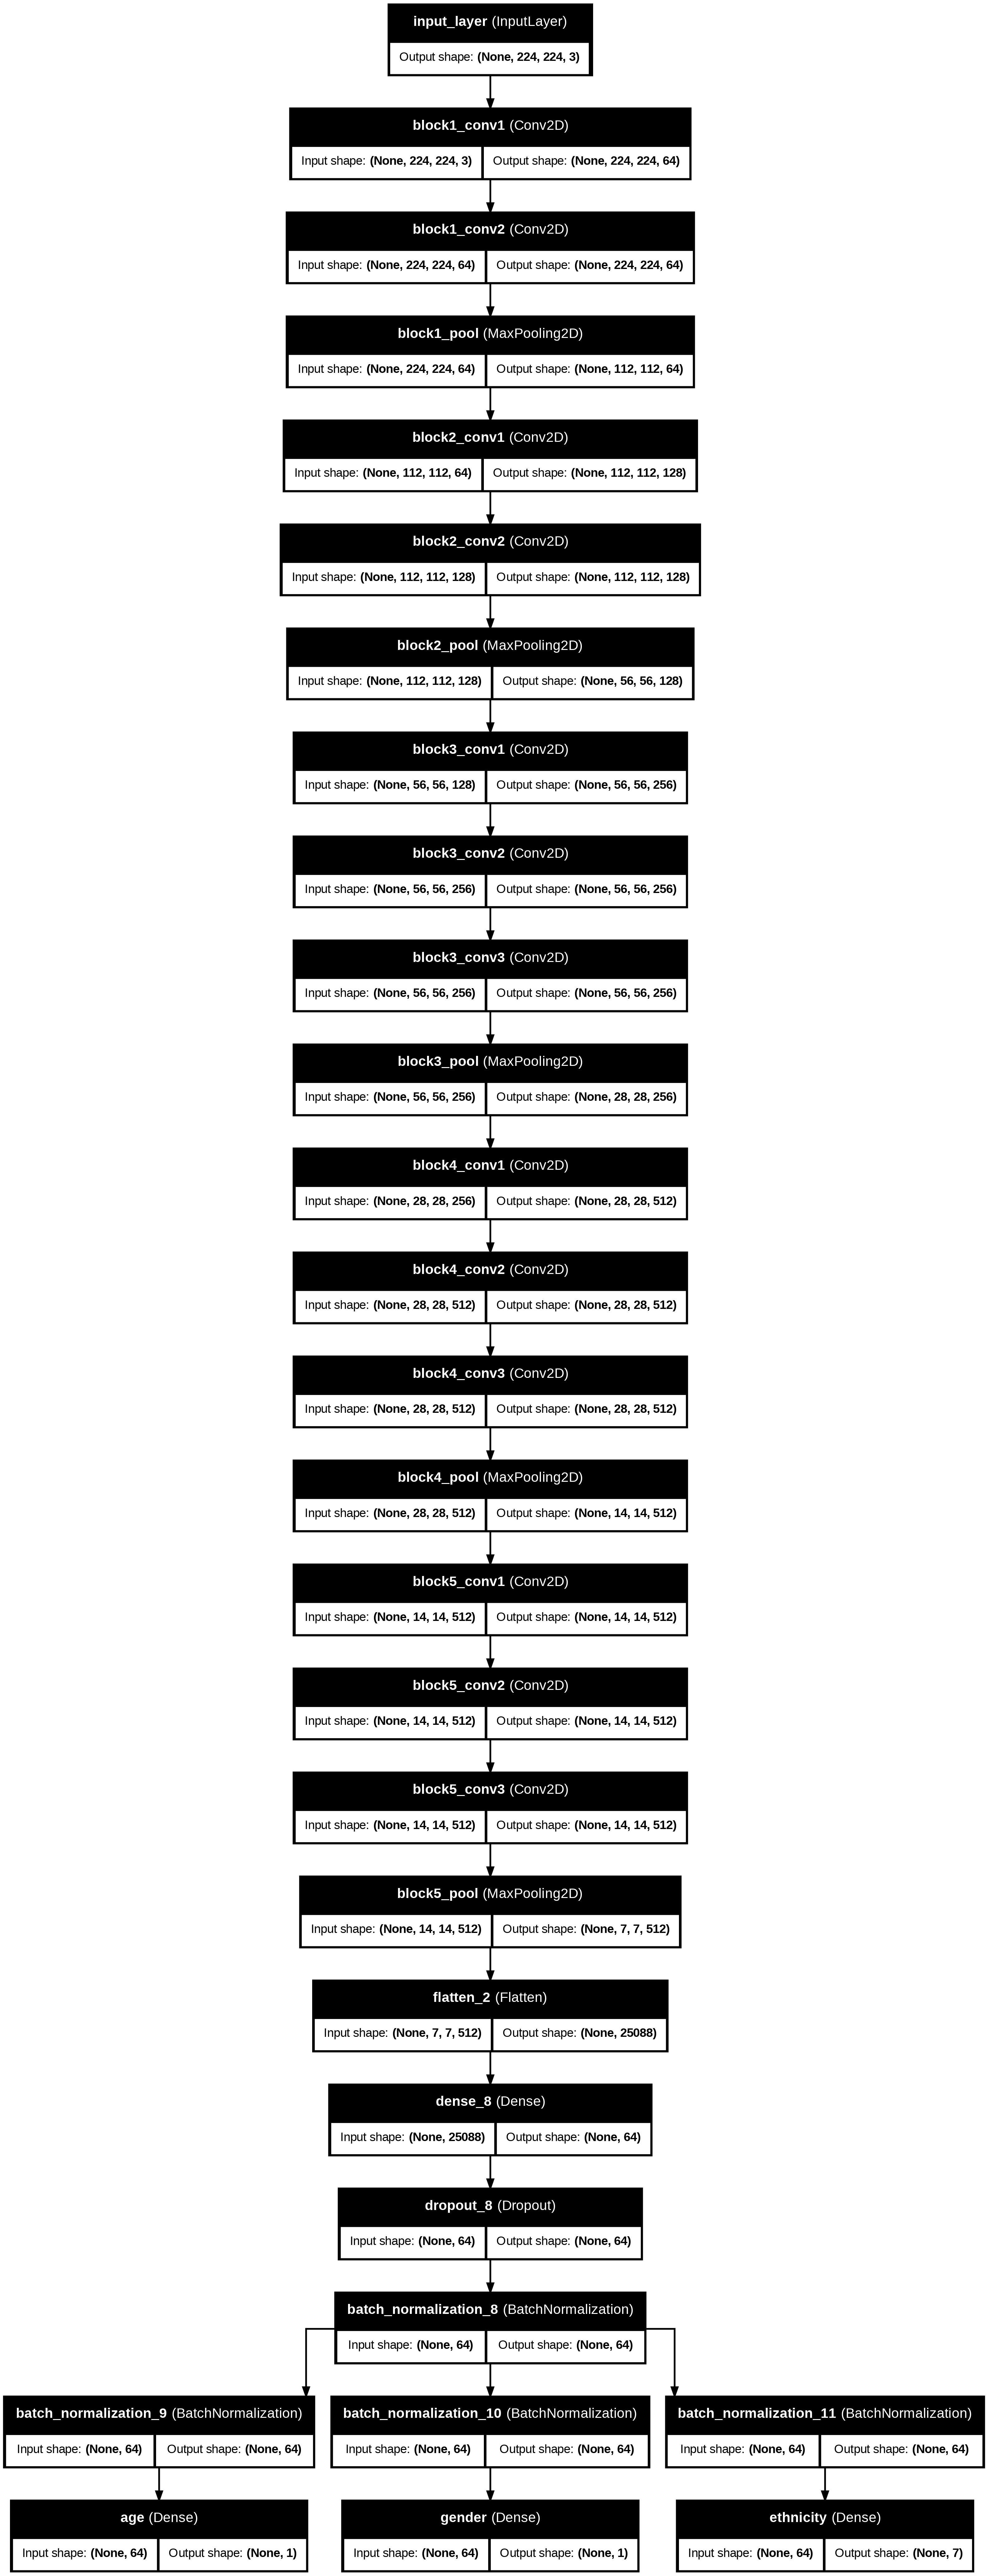

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

# Model Compile and Training

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'age':'mse',
        'gender':'binary_crossentropy',
        'ethnicity':'sparse_categorical_crossentropy'
    },
    metrics={
        'age':'mae',
        'gender':'accuracy',
        'ethnicity':'accuracy'
    }
)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df)//batch_size,
    validation_data=val_generator,
    validation_steps=len(test_df)//batch_size,
    epochs=10,
    batch_size=batch_size,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

# Accuracy Plot

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['age_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_age_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x600 with 0 Axes>